# UJI KONDISI EKSTREM v2 — Model SD Pariwisata DIY

Versi setelah **koreksi penurunan LPE/LPD** (Tahap 0 protokol kalibrasi).

**Prasyarat:** file model sudah memakai `Laju Pertumbuhan Eksternal = 0.27726` dan `Laju Penurunan Dasar = 0.207945`.

## Perubahan terhadap skrip lama (`uji_kondisi_ekstrem_final.py`)

| No | Perubahan |
|---|---|
| 1 | E15: nilai uji 0,8059 → **0,83178** (3 × LPE baru) |
| 2 | E15 dijalankan pada **TIME STEP 0,25** (lihat `TIME_STEP_UJI`); uji lain tetap TIME STEP 1 |
| 3 | `jalankan()` menerima `final_time` dan `time_step` |
| 4 | Sheet **Simulasi Dasar** membandingkan BASE v2 dengan BASE lama + selisih persen |
| 5 | Sheet baru **Diagnostik E15** (TIME STEP 1 / 0,5 / 0,25 / 0,125 dan nilai lama 0,8059) |
| 6 | Sheet baru **Uji Galat Integrasi** (BASE pada TIME STEP 1 vs 0,5) |
| 7 | Sheet baru **Horizon 2150** + tahun puncak |
| 8 | Grafik tambahan `E15_diagnostik_TIME_STEP.png` |

Tidak berubah: 17 uji, teks hipotesis, enam aturan logika fisik, `UJI_TANPA_KRITERIA_LEDAK = {E02, E15}`, struktur tabel termasuk tiga kolom isian manual, dan 17 grafik uji.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!pip install pysd openpyxl matplotlib -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 11.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.2/150.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.5/919.5 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.4/268.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 6.6 MB/s eta 0:00:00


In [3]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pysd

warnings.filterwarnings("ignore")

# --- sesuaikan path bila perlu ---
FILE_MODEL = "/content/drive/MyDrive/Skripsi_Citra/Pengujian Model Sistem Dinamis/[02] Uji Perilaku/Kalibrasi/MODEL SISTEM DINAMIS.mdl"
FOLDER_OUT = Path("/content/drive/MyDrive/Skripsi_Citra/Pengujian Model Sistem Dinamis/[02] Uji Perilaku/Kalibrasi")
FOLDER_OUT.mkdir(parents=True, exist_ok=True)

LUAS_LAHAN = 317036          # hektar, luas wilayah DIY
BATAS_DAYA_TARIK = 3         # ambang kewajaran indeks daya tarik
KELIPATAN_LEDAK = 5          # wisatawan 2050 maksimum = 5 x simulasi dasar

if not Path(FILE_MODEL).exists():
    from google.colab import files
    print(f"'{FILE_MODEL}' belum ada, silakan upload:")
    files.upload()

In [4]:
model_awal = pysd.read_vensim(FILE_MODEL)
NAMA_TPK = [k for k in model_awal.namespace if "TPK" in k and "Ambang" not in k][0]
NAMA_RP = "Rasio Permintaan terhadap Kapasitas Kamar"

VARIABEL = [
    "Jumlah Wisatawan", "Daya Tarik Destinasi Wisata", "Kepadatan Wisatawan",
    NAMA_TPK, NAMA_RP, "Rasio Daya Dukung Lahan", "Lahan Terbangun",
    "Jumlah Hotel dan Akomodasi", "Laju Konstruksi Hotel dan Akomodasi",
    "Laju Demolisi Hotel dan Akomodasi", "Jumlah Objek Daya Tarik Wisata",
    "Laju Penutupan ODTW", "PDRB Sektor Pariwisata", "Investasi Sektor Pariwisata",
    "Tenaga Kerja Pariwisata", "Tenaga Kerja Dibutuhkan", "Intensitas Tenaga Kerja",
    "Laju Penyerapan Tenaga Kerja Pariwisata", "Laju Keluar Tenaga Kerja Pariwisata",
    "Laju Konversi Lahan Pariwisata", "Laju Konversi Lahan Non Pariwisata",
]
STOK = ["Jumlah Wisatawan", "Jumlah Hotel dan Akomodasi",
        "Jumlah Objek Daya Tarik Wisata", "Tenaga Kerja Pariwisata", "Lahan Terbangun"]
print("Model terbaca. Variabel TPK:", NAMA_TPK)

Model terbaca. Variabel TPK: "Tingkat Penghunian Kamar (TPK)"


## Daftar uji

Parameter, nilai ekstrem, dan hipotesis ditulis **sebelum** simulasi. Kolom terakhir adalah variabel yang digambar pada grafik dokumentasi.

In [6]:
UJI = [
    ("E01", "Wisatawan", {"Laju Pertumbuhan Eksternal": 0},
     "Tanpa kedatangan: wisatawan turun eksponensial mendekati nol tanpa nilai negatif; "
     "Daya Tarik tidak boleh melonjak di atas kondisi tahun dasar.",
     ["Jumlah Wisatawan", "Daya Tarik Destinasi Wisata"]),

    ("E02", "Wisatawan", {"Laju Penurunan Dasar": 0},
     "Tanpa penurunan: wisatawan tidak pernah turun; rem daya tarik tetap bekerja "
     "menurunkan Daya Tarik di bawah 1.",
     ["Jumlah Wisatawan", "Daya Tarik Destinasi Wisata"]),

    ("E03", "Ekonomi", {"Pengeluaran per Kunjungan": 0},
     "Tanpa belanja wisatawan: PDRB dan investasi nol; konstruksi akomodasi berhenti; "
     "akomodasi, ODTW, dan tenaga kerja menurun; TPK naik tetapi tidak melebihi 1.",
     ["PDRB Sektor Pariwisata", NAMA_TPK]),

    ("E04", "Hotel", {"Rasio Investasi terhadap PDRB": 0},
     "Tanpa investasi: konstruksi akomodasi berhenti dan jumlah akomodasi turun; "
     "TPK naik tetapi tidak melebihi 1; PDRB tetap tumbuh karena wisatawan masih berbelanja.",
     ["Jumlah Hotel dan Akomodasi", NAMA_TPK]),

    ("E05", "Hotel", {"Laju Demolisi Dasar": 0},
     "Tanpa demolisi: jumlah akomodasi tidak pernah turun dan lebih tinggi dari simulasi dasar.",
     ["Jumlah Hotel dan Akomodasi", "Laju Konstruksi Hotel dan Akomodasi"]),

    ("E06", "Hotel", {"TPK Ambang": 1},
     "Ambang setinggi kapasitas penuh: konstruksi berhenti selama permintaan belum melampaui "
     "kapasitas, dan aktif kembali bila permintaan melebihi 100% kapasitas (hipotesis revisi "
     "setelah perbaikan A).",
     ["Laju Konstruksi Hotel dan Akomodasi", "Jumlah Hotel dan Akomodasi"]),

    ("E07", "Hotel", {"Proporsi Wisatawan Menginap": 0},
     "Tanpa wisatawan menginap: TPK dan Rasio Permintaan nol; konstruksi berhenti; "
     "akomodasi turun hanya karena demolisi.",
     [NAMA_TPK, "Jumlah Hotel dan Akomodasi"]),

    ("E08", "ODTW", {"Sensitivitas ODTW terhadap Investasi": 0,
                     "Laju Pembangunan ODTW Non Investasi": 0},
     "Tanpa pembangunan ODTW: jumlah ODTW turun eksponensial; Daya Tarik turun; "
     "wisatawan memuncak lalu menurun.",
     ["Jumlah Objek Daya Tarik Wisata", "Jumlah Wisatawan"]),

    ("E09", "Lahan", {"Laju Konversi Dasar": 0.436052},
     "Konversi non-pariwisata 10x: lahan terbangun mendekati tetapi tidak melebihi luas wilayah; "
     "Rasio Daya Dukung Lahan tidak negatif; konversi pariwisata berhenti saat lahan habis.",
     ["Lahan Terbangun", "Rasio Daya Dukung Lahan"]),

    ("E10", "Lahan", {"Kebijakan Konservasi Lahan": 1},
     "Konservasi penuh: konversi lahan pariwisata nol; konversi non-pariwisata tetap berjalan.",
     ["Laju Konversi Lahan Pariwisata", "Lahan Terbangun"]),

    ("E11", "Lahan", {"Lahan Per Hotel dan Akomodasi": 0, "Lahan Per ODTW": 0},
     "Tanpa kebutuhan lahan: konversi lahan pariwisata nol; hasil setara dengan E10.",
     ["Laju Konversi Lahan Pariwisata", "Lahan Terbangun"]),

    ("E12", "Tenaga Kerja", {"Laju Kenaikan Produktivitas": 0},
     "Produktivitas tetap: intensitas tenaga kerja konstan sehingga tenaga kerja tumbuh "
     "sebanding PDRB dan lebih tinggi dari simulasi dasar; variabel lain tidak berubah.",
     ["Tenaga Kerja Pariwisata", "Intensitas Tenaga Kerja"]),

    ("E13", "Tenaga Kerja", {"Laju Keluar Dasar Tenaga Kerja": 0},
     "Tanpa pekerja keluar: tenaga kerja tetap mengikuti kebutuhan dan tidak menumpuk; "
     "laju penyerapan menurun karena tidak perlu mengganti pekerja yang keluar.",
     ["Tenaga Kerja Pariwisata", "Laju Penyerapan Tenaga Kerja Pariwisata"]),

    ("E14", "Kebijakan", {"Insentif Kebijakan": 5},
     "Insentif sangat besar: konstruksi melonjak, okupansi turun, lalu konstruksi melambat "
     "sendiri (loop balancing okupansi); Daya Tarik tidak lepas kendali.",
     ["Jumlah Hotel dan Akomodasi", NAMA_TPK]),

    # PERUBAHAN 1: 0.8059 -> 0.83178 (3 x LPE baru 0.27726)
    ("E15", "Wisatawan", {"Laju Pertumbuhan Eksternal": 0.83178},
     "Permintaan eksternal 3x: seluruh rem struktural bekerja (Daya Tarik menuju batas bawah, "
     "lahan tidak melebihi luas wilayah, okupansi tidak melebihi 100%).",
     ["Jumlah Wisatawan", "Lahan Terbangun"]),

    ("E16", "ODTW", {"Laju Penutupan Dasar ODTW": 0},
     "Tanpa penutupan ODTW: jumlah ODTW naik monoton dan lebih tinggi dari simulasi dasar; "
     "Daya Tarik lebih tinggi sehingga wisatawan juga lebih banyak.",
     ["Jumlah Objek Daya Tarik Wisata", "Daya Tarik Destinasi Wisata"]),

    ("E17", "Lahan", {"Laju Konversi Dasar": 0},
     "Tanpa konversi non-pariwisata: lahan terbangun hanya bertambah dari konversi pariwisata "
     "sehingga naik sangat lambat; Rasio Daya Dukung Lahan hampir tidak berubah.",
     ["Lahan Terbangun", "Rasio Daya Dukung Lahan"]),
]

UJI_TANPA_KRITERIA_LEDAK = {"E02", "E15"}

# PERUBAHAN 2: langkah waktu khusus per uji.
# Pada E15 konstanta waktu sistem menciut dari ~4,8 tahun menjadi ~1,2 tahun,
# sehingga TIME STEP 1 tidak lagi memadai (Sterman, 2000): pada dt = 1 lahan
# melewati batas 57,70 ha dan pada dt = 0,5 masih +0,01 ha, keduanya galat integrasi.
TIME_STEP_UJI = {"E15": 0.25}

In [7]:
def jalankan(params, final_time=None, time_step=None):
    """Model dibaca ulang tiap run agar parameter uji tidak terbawa ke uji berikutnya."""
    m = pysd.read_vensim(FILE_MODEL)
    kw = dict(params=params, return_columns=VARIABEL)
    akhir = final_time or 2050
    if final_time or time_step:
        kw["return_timestamps"] = list(range(2025, akhir + 1))
    if final_time:
        kw["final_time"] = final_time
    if time_step:
        kw["time_step"] = time_step          # catatan: params={"TIME STEP": ...} TIDAK berfungsi di PySD
    hasil = m.run(**kw)
    return hasil.apply(lambda s: np.real(s.astype(complex)))


def periksa_aturan(r, kode, dasar):
    """Enam aturan logika fisik. Mengembalikan daftar pelanggaran."""
    langgar = []
    if not np.isfinite(r.values).all():
        langgar.append("terdapat nilai tak hingga/NaN")
    for s in STOK:
        if (r[s] < -1e-6).any():
            langgar.append(f"{s} bernilai negatif")
    if (r[NAMA_TPK] > 1 + 1e-9).any():
        langgar.append(f"TPK > 1 (maks {r[NAMA_TPK].max():.3f})")
    if (r["Rasio Daya Dukung Lahan"] < -1e-9).any():
        langgar.append(f"Rasio Daya Dukung Lahan < 0 (min {r['Rasio Daya Dukung Lahan'].min():.3f})")
    if (r["Lahan Terbangun"] > LUAS_LAHAN + 1e-6).any():
        langgar.append(f"Lahan Terbangun > luas wilayah (maks {r['Lahan Terbangun'].max():,.0f} ha)")
    dt = r["Daya Tarik Destinasi Wisata"]
    if (dt > BATAS_DAYA_TARIK).any() or (dt < 0).any():
        langgar.append(f"Daya Tarik di luar batas ({dt.min():.3f}-{dt.max():.3f})")
    if kode not in UJI_TANPA_KRITERIA_LEDAK and dasar is not None:
        if r["Jumlah Wisatawan"].iloc[-1] > KELIPATAN_LEDAK * dasar["Jumlah Wisatawan"].iloc[-1]:
            langgar.append(f"Wisatawan meledak ({r['Jumlah Wisatawan'].iloc[-1]/1e6:,.0f} juta di 2050)")
    return langgar

## Simulasi dasar dan 17 uji

In [8]:
dasar = jalankan({})
hasil_run = {"BASE": dasar}
baris = []

print(f"Jumlah Wisatawan 2026 (cek koreksi LPE): {dasar['Jumlah Wisatawan'][2026]:,.0f}   (harus ≈ 43.516.522)\n")
print(f"{'Kode':<6}{'Status':<26}{'Pemeriksaan aturan logika'}")
print("-" * 95)
for kode, sub, params, hipotesis, _ in UJI:
    ts = TIME_STEP_UJI.get(kode)
    r = jalankan(params, time_step=ts)
    hasil_run[kode] = r
    langgar = periksa_aturan(r, kode, dasar)

    if langgar:
        status = "GAGAL"
    elif kode in UJI_TANPA_KRITERIA_LEDAK:
        status = "LOLOS DENGAN CATATAN"
    else:
        status = "LOLOS"

    nilai_uji = "; ".join(f"{k} = {v}" for k, v in params.items())
    if ts:
        nilai_uji += f"; TIME STEP = {ts}"

    baris.append({
        "Kode": kode,
        "Subsistem": sub,
        "Parameter dan nilai uji": nilai_uji,
        "Hipotesis perilaku": hipotesis,
        "Wisatawan 2050 (juta)": r["Jumlah Wisatawan"].iloc[-1] / 1e6,
        "Hotel 2050": r["Jumlah Hotel dan Akomodasi"].iloc[-1],
        "ODTW 2050": r["Jumlah Objek Daya Tarik Wisata"].iloc[-1],
        "Tenaga Kerja 2050 (ribu)": r["Tenaga Kerja Pariwisata"].iloc[-1] / 1e3,
        "Lahan Terbangun 2050 (ha)": r["Lahan Terbangun"].iloc[-1],
        "TPK maks": r[NAMA_TPK].max(),
        "Rasio Permintaan maks": r[NAMA_RP].max(),
        "Rasio Daya Dukung min": r["Rasio Daya Dukung Lahan"].min(),
        "Daya Tarik min": r["Daya Tarik Destinasi Wisata"].min(),
        "Daya Tarik maks": r["Daya Tarik Destinasi Wisata"].max(),
        "Pemeriksaan aturan logika": "Lolos" if not langgar else "; ".join(langgar),
        "Status": status,
        "Penilaian kesesuaian hipotesis (isi manual)": "",
        "Akar masalah (isi manual)": "",
        "Perbaikan struktur (isi manual)": "",
    })
    print(f"{kode:<6}{status:<26}{'Lolos' if not langgar else '; '.join(langgar)}")

tabel = pd.DataFrame(baris)
print("\nRingkasan status:")
print(tabel["Status"].value_counts().to_string())

Jumlah Wisatawan 2026 (cek koreksi LPE): 43,516,522   (harus ≈ 43.516.522)

Kode  Status                    Pemeriksaan aturan logika
-----------------------------------------------------------------------------------------------
E01   LOLOS                     Lolos
E02   LOLOS DENGAN CATATAN      Lolos
E03   LOLOS                     Lolos
E04   LOLOS                     Lolos
E05   LOLOS                     Lolos
E06   LOLOS                     Lolos
E07   LOLOS                     Lolos
E08   LOLOS                     Lolos
E09   LOLOS                     Lolos
E10   LOLOS                     Lolos
E11   LOLOS                     Lolos
E12   LOLOS                     Lolos
E13   LOLOS                     Lolos
E14   LOLOS                     Lolos
E15   LOLOS DENGAN CATATAN      Lolos
E16   LOLOS                     Lolos
E17   LOLOS                     Lolos

Ringkasan status:
Status
LOLOS                   15
LOLOS DENGAN CATATAN     2


## Simulasi dasar: BASE v2 vs BASE lama

In [9]:
VAR_RINGKAS = ["Jumlah Wisatawan", "Daya Tarik Destinasi Wisata", NAMA_TPK, "Rasio Daya Dukung Lahan",
               "Lahan Terbangun", "Jumlah Hotel dan Akomodasi", "Jumlah Objek Daya Tarik Wisata",
               "Tenaga Kerja Pariwisata", "PDRB Sektor Pariwisata", "Investasi Sektor Pariwisata"]

BASE_LAMA = {"Jumlah Wisatawan": 94692357, "Daya Tarik Destinasi Wisata": 0.814, NAMA_TPK: 0.358,
             "Rasio Daya Dukung Lahan": 0.615, "Lahan Terbangun": 122192,
             "Jumlah Hotel dan Akomodasi": 5323, "Jumlah Objek Daya Tarik Wisata": 364,
             "Tenaga Kerja Pariwisata": 640325, "PDRB Sektor Pariwisata": 39434,
             "Investasi Sektor Pariwisata": 1925}

ringkas_dasar = pd.DataFrame({
    "Variabel": [v.strip('"') for v in VAR_RINGKAS],
    "2025 (BASE v2)": [float(dasar[v][2025]) for v in VAR_RINGKAS],
    "2050 (BASE v2)": [float(dasar[v][2050]) for v in VAR_RINGKAS],
    "2050 (BASE lama, LPE 0,26864)": [BASE_LAMA[v] for v in VAR_RINGKAS],
})
ringkas_dasar["Selisih 2050 (%)"] = 100 * (ringkas_dasar["2050 (BASE v2)"] -
    ringkas_dasar["2050 (BASE lama, LPE 0,26864)"]) / ringkas_dasar["2050 (BASE lama, LPE 0,26864)"]
ringkas_dasar.round(4)

,Variabel,2025 (BASE v2),2050 (BASE v2),"2050 (BASE lama, LPE 0,26864)",Selisih 2050 (%)
0,Jumlah Wisatawan,4.069570e+07,9.619715e+07,9.469236e+07,1.5891
1,Daya Tarik Destinasi Wisata,1.000000e+00,8.132000e-01,8.140000e-01,-0.0930
2,Tingkat Penghunian Kamar (TPK),3.576000e-01,3.584000e-01,3.580000e-01,0.1021
3,Rasio Daya Dukung Lahan,8.264000e-01,6.145000e-01,6.150000e-01,-0.0763
4,Lahan Terbangun,5.502950e+04,1.222076e+05,1.221920e+05,0.0128
5,Jumlah Hotel dan Akomodasi,2.291000e+03,5.404370e+03,5.323000e+03,1.5286
6,Jumlah Objek Daya Tarik Wisata,2.010000e+02,3.672417e+02,3.640000e+02,0.8906
7,Tenaga Kerja Pariwisata,3.649940e+05,6.503552e+05,6.403250e+05,1.5664
8,PDRB Sektor Pariwisata,1.694764e+04,4.006110e+04,3.943400e+04,1.5902
9,Investasi Sektor Pariwisata,8.273395e+02,1.955679e+03,1.925000e+03,1.5937


## Diagnostik E15: apakah pelanggaran lahan bersifat numerik?

Jika pelanggaran menyusut saat TIME STEP diperkecil, penyebabnya galat integrasi, bukan struktur.

In [10]:
diag, run_diag = [], {}
for label, par, ts in [("E15 (LPE 0,83178), TIME STEP 1", {"Laju Pertumbuhan Eksternal": 0.83178}, None),
                       ("E15 (LPE 0,83178), TIME STEP 0,5", {"Laju Pertumbuhan Eksternal": 0.83178}, 0.5),
                       ("E15 (LPE 0,83178), TIME STEP 0,25  <-- hasil resmi", {"Laju Pertumbuhan Eksternal": 0.83178}, 0.25),
                       ("E15 (LPE 0,83178), TIME STEP 0,125", {"Laju Pertumbuhan Eksternal": 0.83178}, 0.125),
                       ("E15 nilai lama (LPE 0,8059), TIME STEP 1", {"Laju Pertumbuhan Eksternal": 0.8059}, None)]:
    r = jalankan(par, time_step=ts)
    run_diag[label] = r
    diag.append({"Kondisi": label,
                 "Lahan maksimum (ha)": r["Lahan Terbangun"].max(),
                 "Selisih terhadap 317.036 ha": r["Lahan Terbangun"].max() - LUAS_LAHAN,
                 "RDDL minimum": r["Rasio Daya Dukung Lahan"].min(),
                 "Konversi pariwisata 2049 (ha)": float(r["Laju Konversi Lahan Pariwisata"][2049]),
                 "Status aturan lahan": "Dilanggar" if r["Lahan Terbangun"].max() > LUAS_LAHAN + 1e-6 else "Lolos"})

diagnostik_E15 = pd.DataFrame(diag)
diagnostik_E15.round(4)

,Kondisi,Lahan maksimum (ha),Selisih terhadap 317.036 ha,RDDL minimum,Konversi pariwisata 2049 (ha),Status aturan lahan
0,"E15 (LPE 0,83178), TIME STEP 1",317093.7049,57.7049,0.0000,823.5116,Dilanggar
1,"E15 (LPE 0,83178), TIME STEP 0,5",317036.0126,0.0126,0.0000,88.2938,Dilanggar
2,"E15 (LPE 0,83178), TIME STEP 0,25 <-- hasil r...",317035.8176,-0.1824,0.0000,29.7885,Lolos
3,"E15 (LPE 0,83178), TIME STEP 0,125",317035.8764,-0.1236,0.0000,17.2572,Lolos
4,"E15 nilai lama (LPE 0,8059), TIME STEP 1",316213.8913,-822.1087,0.0026,3796.0027,Lolos


## Uji galat integrasi pada simulasi dasar

Membandingkan BASE pada TIME STEP 1 dan 0,5 (Sterman, 2000). Selisih kecil berarti TIME STEP 1 memadai untuk daerah parameter yang berlaku.

In [11]:
dasar_05 = jalankan({}, time_step=0.5)
uji_integrasi = pd.DataFrame({
    "Variabel": [v.strip('"') for v in VAR_RINGKAS],
    "2050 TIME STEP 1": [float(dasar[v][2050]) for v in VAR_RINGKAS],
    "2050 TIME STEP 0,5": [float(dasar_05[v][2050]) for v in VAR_RINGKAS],
})
uji_integrasi["Selisih (%)"] = 100 * (uji_integrasi["2050 TIME STEP 0,5"] -
    uji_integrasi["2050 TIME STEP 1"]) / uji_integrasi["2050 TIME STEP 1"]
uji_integrasi.round(4)

,Variabel,2050 TIME STEP 1,"2050 TIME STEP 0,5",Selisih (%)
0,Jumlah Wisatawan,9.619715e+07,9.594035e+07,-0.2670
1,Daya Tarik Destinasi Wisata,8.132000e-01,8.132000e-01,-0.0030
2,Tingkat Penghunian Kamar (TPK),3.584000e-01,3.584000e-01,0.0024
3,Rasio Daya Dukung Lahan,6.145000e-01,6.132000e-01,-0.2104
4,Lahan Terbangun,1.222076e+05,1.226175e+05,0.3354
5,Jumlah Hotel dan Akomodasi,5.404370e+03,5.389814e+03,-0.2693
6,Jumlah Objek Daya Tarik Wisata,3.672417e+02,3.671655e+02,-0.0207
7,Tenaga Kerja Pariwisata,6.503552e+05,6.485722e+05,-0.2742
8,PDRB Sektor Pariwisata,4.006110e+04,3.995415e+04,-0.2670
9,Investasi Sektor Pariwisata,1.955679e+03,1.950458e+03,-0.2670


## Horizon diperpanjang sampai 2150 (Barlas, 1996)

In [12]:
h = jalankan({}, final_time=2150)
horizon = h.loc[[2050, 2075, 2100, 2125, 2150], VAR_RINGKAS].round(4)
horizon.index.name = "Tahun"

puncak = pd.DataFrame({
    "Keterangan": ["Puncak Jumlah Wisatawan (juta)", "Tahun puncak", "Lahan Terbangun maksimum (ha)",
                   "TPK maksimum", "Daya Tarik minimum"],
    "Nilai": [h["Jumlah Wisatawan"].max() / 1e6, float(h["Jumlah Wisatawan"].idxmax()),
              h["Lahan Terbangun"].max(), h[NAMA_TPK].max(), h["Daya Tarik Destinasi Wisata"].min()]})
display(horizon)
display(puncak)

,Jumlah Wisatawan,Daya Tarik Destinasi Wisata,"""Tingkat Penghunian Kamar (TPK)""",Rasio Daya Dukung Lahan,Lahan Terbangun,Jumlah Hotel dan Akomodasi,Jumlah Objek Daya Tarik Wisata,Tenaga Kerja Pariwisata,PDRB Sektor Pariwisata,Investasi Sektor Pariwisata
Tahun,,,,,,,,,,
2050,9.619715e+07,0.8132,0.3584,0.6145,122207.6209,5404.3699,367.2417,650355.2026,40061.0961,1955.6786
2075,1.222254e+08,0.7577,0.3422,0.3464,207210.3554,7191.1482,534.3921,637138.5034,50900.4947,2484.8298
2100,1.137918e+08,0.7246,0.3315,0.1488,269864.0094,6910.0635,596.6782,454615.3943,47388.3576,2313.3764
2125,9.129899e+07,0.7152,0.3278,0.0543,299836.5315,5607.7523,556.0468,277704.9031,38021.2670,1856.0994
2150,7.264851e+07,0.7209,0.3291,0.0184,311189.5468,4444.1945,479.7727,167510.7197,30254.3127,1476.9369


,Keterangan,Nilai
0,Puncak Jumlah Wisatawan (juta),122.935325
1,Tahun puncak,2080.000000
2,Lahan Terbangun maksimum (ha),311189.546831
3,TPK maksimum,0.388363
4,Daya Tarik minimum,0.715214


## Simpan tabel Excel

In [13]:
berkas_excel = FOLDER_OUT / "hasil_uji_kondisi_ekstrem_v2.xlsx"
with pd.ExcelWriter(berkas_excel) as writer:
    tabel.to_excel(writer, sheet_name="Uji Kondisi Ekstrem", index=False)
    ringkas_dasar.to_excel(writer, sheet_name="Simulasi Dasar", index=False)
    diagnostik_E15.to_excel(writer, sheet_name="Diagnostik E15", index=False)
    uji_integrasi.to_excel(writer, sheet_name="Uji Galat Integrasi", index=False)
    horizon.to_excel(writer, sheet_name="Horizon 2150")
    puncak.to_excel(writer, sheet_name="Horizon 2150", index=False, startrow=len(horizon) + 3)
    for kode in ["BASE"] + [u[0] for u in UJI]:
        hasil_run[kode].round(4).to_excel(writer, sheet_name=f"Seri {kode}"[:31])
print("Tabel tersimpan:", berkas_excel)

Tabel tersimpan: /content/drive/MyDrive/Skripsi_Citra/Pengujian Model Sistem Dinamis/[02] Uji Perilaku/Kalibrasi/hasil_uji_kondisi_ekstrem_v2.xlsx


## Grafik dokumentasi

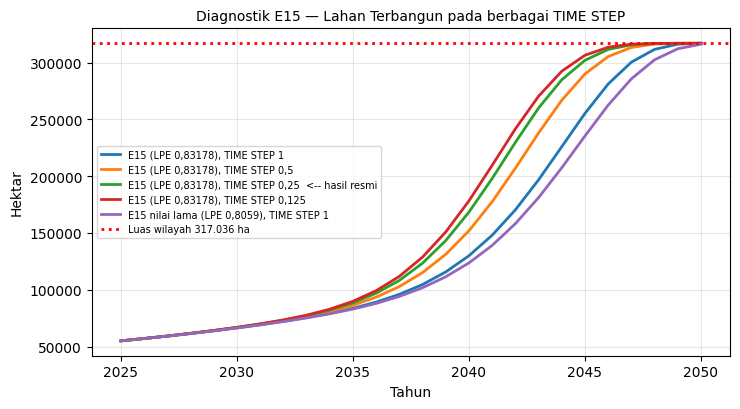

Grafik tersimpan: 18 berkas PNG di folder '/content/drive/MyDrive/Skripsi_Citra/Pengujian Model Sistem Dinamis/[02] Uji Perilaku/Kalibrasi'


In [14]:
for kode, sub, params, hipotesis, grafik in UJI:
    r = hasil_run[kode]
    fig, axes = plt.subplots(1, len(grafik), figsize=(5.5 * len(grafik), 3.8))
    axes = np.atleast_1d(axes)
    for ax, v in zip(axes, grafik):
        ax.plot(dasar.index, dasar[v], label="Simulasi dasar", lw=2)
        ax.plot(r.index, r[v], label=f"Uji {kode}", lw=2, ls="--")
        ax.set_title(v.strip('"'), fontsize=10)
        ax.set_xlabel("Tahun")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    judul = "; ".join(f"{k} = {val}" for k, val in params.items())
    if kode in TIME_STEP_UJI:
        judul += f"; TIME STEP = {TIME_STEP_UJI[kode]}"
    fig.suptitle(f"{kode} — {judul}", fontsize=10)
    fig.tight_layout()
    fig.savefig(FOLDER_OUT / f"{kode}.png", dpi=150)
    plt.close(fig)

# Grafik diagnostik E15
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for label, r in run_diag.items():
    ax.plot(r.index, r["Lahan Terbangun"], lw=2, label=label)
ax.axhline(LUAS_LAHAN, color="red", ls=":", lw=2, label="Luas wilayah 317.036 ha")
ax.set_xlabel("Tahun"); ax.set_ylabel("Hektar"); ax.grid(alpha=0.3); ax.legend(fontsize=7)
ax.set_title("Diagnostik E15 — Lahan Terbangun pada berbagai TIME STEP", fontsize=10)
fig.tight_layout()
fig.savefig(FOLDER_OUT / "E15_diagnostik_TIME_STEP.png", dpi=150)
plt.show()

print(f"Grafik tersimpan: {len(UJI) + 1} berkas PNG di folder '{FOLDER_OUT}'")

## Catatan untuk penulisan Bab IV

- Rekap akhir: **15 LOLOS, 2 LOLOS DENGAN CATATAN (E02, E15), 0 GAGAL**.
- Catatan E15 ada dua: (1) kriteria kewajaran besaran tidak diterapkan karena uji ini menaikkan pendorong pertumbuhan; (2) pada TIME STEP 1 lahan melewati batas 57,70 ha (0,018%) dan pada 0,5 masih +0,01 ha, keduanya galat integrasi, sehingga uji dilaporkan pada TIME STEP 0,25.
- Tambahkan subbab pendek **Uji Galat Integrasi** memakai sheet *Uji Galat Integrasi* dan *Diagnostik E15* beserta grafiknya.
- Keterbatasan baru: model memakai langkah waktu tahunan mengikuti data tahunan, sehingga pada kondisi parameter jauh di luar batas keberlakuan (LPE ≤ 0,346575) diperlukan langkah waktu lebih kecil agar hasilnya sahih secara numerik.
- Cek bibliografi: pedoman langkah waktu ≤ seperempat konstanta waktu tercepat ada pada Sterman (2000); nomor bab dan halamannya perlu dikonfirmasi sendiri.